In [282]:
%load_ext autoreload
%autoreload 2

# import packages
import xarray as xr
import geopandas as gpd
import numpy as np
# import partial packages
from kmodes.kprototypes import KPrototypes
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import pandas as pd

directory = '/scratch/6256481/'

import sys
sys.path.insert(0, directory + f'python/py_code/')

from run_confinement_values import concat_reachAveraged


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Open and transform data

In [283]:
f = directory + 'results/single_smoothed/eu_50_02_smoothed.nc'
ds = xr.open_dataset(f)

In [286]:
df = ds.to_dataframe().reset_index()


In [291]:
df.columns

Index(['index', 'combined_reach_id', 'reach_id', 'file', 'bendLen',
       'up_reach_id', 'networkGraph', 'networkGroup', 'river_name',
       'dn_connected_reach', 'rch_id_dn', 'rch_id_dn_orig', 'rch_id_up',
       'rch_id_up_orig', 'combined_reach_up', 'combined_reach_dn', 'ER_inn',
       'ER_out', 'slope_inn', 'slope_out', 'ER_left', 'ER_right', 'slope_left',
       'slope_right', 'apex', 'catchment_position', 'bendWidths',
       'bendMaxWidths', 'cp_height', 'cm_height', 'bendDistOut',
       'max_dist_out', 'bendHeight', 'bendSin', 'sin', 'ang', 'conFactor',
       'combined_reach_len', 'ER_max_inout', 'slope_max_inout',
       'slope_diff_bendSide', 'slope_diff_bendSide_abs', 'slope_diff_side',
       'ER_diff_bendSide', 'ER_diff_bendSide_abs', 'ER_diff_side', 'nonDimAmp',
       'catch_height', 'slope_max', 'slope_out_normalized',
       'slope_inn_normalized', 'slope_left_normalized',
       'slope_right_normalized', 'bend_catch_pos', 'glob_reach_id', 'bendRank',
       'bend

In [288]:
labelTextSize = 15

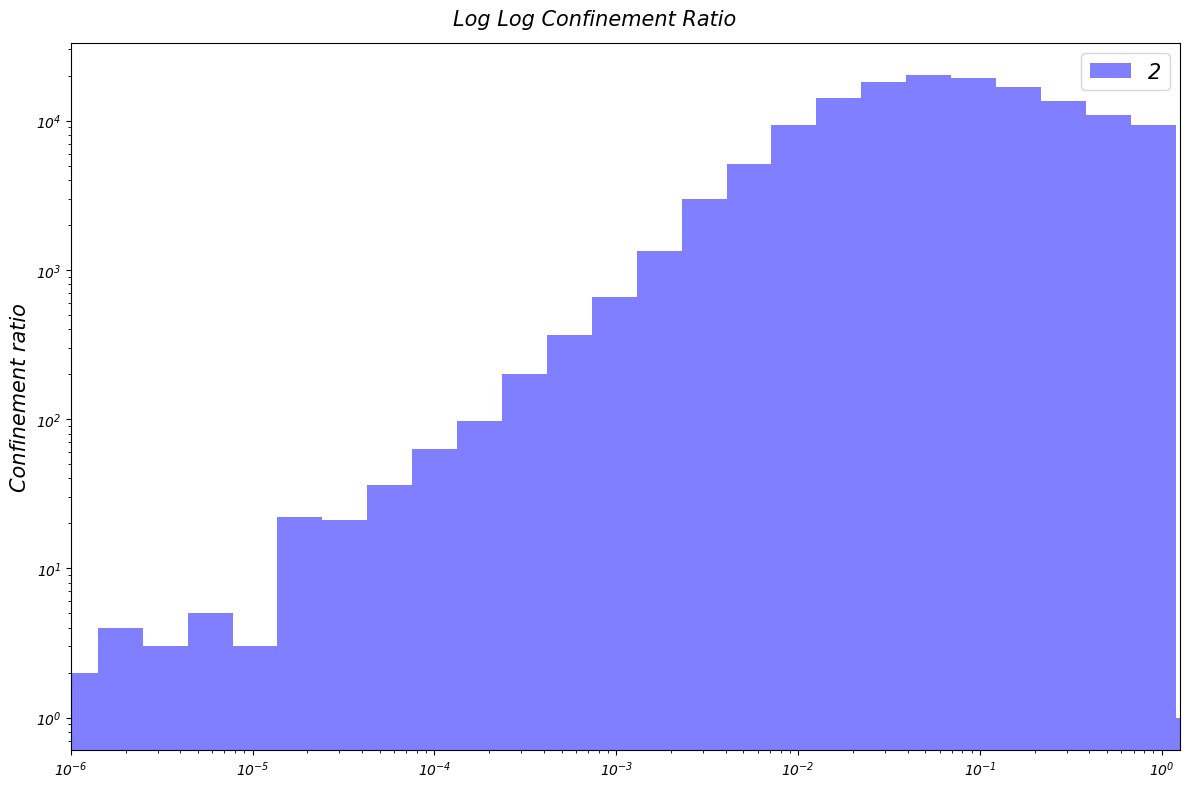

In [316]:
f, ax = plt.subplots(nrows = 1, ncols = 1, figsize  = [12,8], squeeze = False)
X = ['slope_inn_normalized_smooth']
# X = ['ER_out_2', 'ER_out_4']
color = ['blue', 'red', 'green', 'yellow']
leg = ['2', '4', '8', '15']
c = r = 0
for i in range(len(X)):
    x = df[X[i]]
    if x.min() <= 0:
        x = x[x > 0]
    bin_edges = np.logspace(np.log10(x.min()), np.log10(x.max()), num=800)

    # Create histogram
    ax[r,c].hist(x, bins=bin_edges, alpha=0.5, color = color[i], label = leg[i])
ax[r,c].set_xscale('log')
ax[r,c].set_yscale('log')
ax[r,c].set_ylabel('Count'            , fontsize = labelTextSize)
ax[r,c].set_ylabel('Confinement ratio', fontsize = labelTextSize)

f.suptitle('Log Log Confinement Ratio', fontsize = labelTextSize)
plt.tight_layout()
plt.legend(fontsize = labelTextSize)
# plt.ylim([10**2,10**5])
plt.xlim([10**-6,10**0.1])
plt.show()

In [83]:
f = directory + 'results/single_values/global_50_02_conf.nc'
ds = xr.open_dataset(f)

In [84]:
dsSubset = ds[[
    'combined_reach_id', 'reach_id', 'file', 'bendLen', 'up_reach_id', 
    'networkGraph', 'networkGroup', 'river_name',
    'dn_connected_reach', 'rch_id_dn', 'rch_id_dn_orig', 'rch_id_up', 'rch_id_up_orig',
    'combined_reach_up', 'combined_reach_dn',
    'river_segment', 'river_segment_order',
    'ER_inn', 'ER_out', 'slope_inn', 'slope_out',
    'ER_left', 'ER_right', 'slope_left', 'slope_right',
    'apex', 'catchment_position', 'bendWidths', 'bendMaxWidths',
    'cp_height', 'cm_height','bendDistOut','max_dist_out','bendHeight',
    'sin', 'ang', 'conFactor', 'catchment_position', 'combined_reach_len'
    ]]
df = dsSubset.to_dataframe().reset_index()

df['ER_max_inout']    = df[['ER_inn', 'ER_out']].max(axis = 1)
df['slope_max_inout'] = df[['slope_inn', 'slope_out']].max(axis = 1)


df['slope_diff_bendSide']     = df['slope_inn']     - df['slope_out']
df['slope_diff_bendSide_abs'] = abs(df['slope_inn'] - df['slope_out'])
df['slope_diff_side']         = df['slope_left']    - df['slope_right']


df['ER_diff_bendSide']     = df['ER_inn']     - df['ER_out']
df['ER_diff_bendSide_abs'] = abs(df['ER_inn'] - df['ER_out'])
df['ER_diff_side']         = df['ER_left']    - df['ER_right']

df['nonDimAmp'] = df['apex'] / df['bendMaxWidths']

df['catch_height'] = df['bendHeight'] * df['catchment_position']

df['slope_max'] = (df['cm_height'] - df['cp_height']) / (df['bendMaxWidths']*0.5)
df['slope_out_normalized'] = df['slope_out']   / df['slope_max']
df['slope_inn_normalized'] = df['slope_inn']   / df['slope_max']
df['slope_left_normalized'] = df['slope_left']  / df['slope_max']
df['slope_right_normalized'] = df['slope_right'] / df['slope_max']


df['bend_catch_pos'] = df['bendDistOut'] / df['max_dist_out']

df['glob_reach_id'] = df.groupby(['file', 'combined_reach_id']).ngroup()
dfG = df.groupby(['glob_reach_id'], as_index = False)[['file', 'combined_reach_id', 'combined_reach_len', 'sin']].first()


In [4]:
# Define which columns to apply which aggregations
first_columns = ['file', 'combined_reach_id']
# agg_columns = ['ER_left'    , 'ER_right'  , 'ER_out'   , 'ER_inn', 
            #    'slope_right', 'slope_left', 'slope_out', 'slope_inn']
agg_columns = ['slope_right_normalized', 'slope_left_normalized', 'slope_out_normalized', 'slope_inn_normalized']

# Build aggregation dictionary
agg_dict = {col: 'first' for col in first_columns}
agg_dict.update({col: ['mean', 'std', 'min', 'max', 'median'] for col in agg_columns})

# Apply groupby and aggregations
grouped = df.groupby("glob_reach_id", as_index = False).agg(agg_dict)

# Optional: flatten multi-level column names
grouped.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in grouped.columns]
grouped = grouped.reset_index()
grouped = grouped.rename(columns = {'glob_reach_id_':'glob_reach_id'})

df  =df.merge(grouped, how = 'left', on = 'glob_reach_id')

In [ ]:
clusterAllColumns  = [col for col in df.columns if 'normalized' in col]
clusterBendColumns = ['slope_out_normalized', 'slope_inn_normalized']
clusterAggColumns  = [col for col in df.columns if 'normalized_' in col]

df[['glob_reach_id'] + clusterAllColumns]
df[['glob_reach_id'] + clusterAllColumns]

,glob_reach_id,slope_out_normalized,slope_inn_normalized,slope_left_normalized,slope_right_normalized,slope_right_normalized_mean,slope_right_normalized_std,slope_right_normalized_min,slope_right_normalized_max,slope_right_normalized_median,...,slope_out_normalized_mean,slope_out_normalized_std,slope_out_normalized_min,slope_out_normalized_max,slope_out_normalized_median,slope_inn_normalized_mean,slope_inn_normalized_std,slope_inn_normalized_min,slope_inn_normalized_max,slope_inn_normalized_median
0,12584,0.295685,0.101925,0.295685,0.101925,0.265644,0.186060,0.054776,0.819673,0.209918,...,0.409147,0.262681,0.060787,1.000000,0.331490,0.265644,0.186060,0.054776,0.819673,0.209918
1,12584,0.060787,0.209918,0.060787,0.209918,0.265644,0.186060,0.054776,0.819673,0.209918,...,0.409147,0.262681,0.060787,1.000000,0.331490,0.265644,0.186060,0.054776,0.819673,0.209918
2,12584,0.265816,0.819673,0.265816,0.819673,0.265644,0.186060,0.054776,0.819673,0.209918,...,0.409147,0.262681,0.060787,1.000000,0.331490,0.265644,0.186060,0.054776,0.819673,0.209918
3,12584,1.000000,0.087275,1.000000,0.087275,0.265644,0.186060,0.054776,0.819673,0.209918,...,0.409147,0.262681,0.060787,1.000000,0.331490,0.265644,0.186060,0.054776,0.819673,0.209918
4,12584,0.139857,0.675535,0.139857,0.675535,0.265644,0.186060,0.054776,0.819673,0.209918,...,0.409147,0.262681,0.060787,1.000000,0.331490,0.265644,0.186060,0.054776,0.819673,0.209918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1492202,85366,-0.000602,0.001271,-0.000602,0.001271,0.003083,0.003780,-0.004633,0.010066,0.002628,...,0.003233,0.005803,-0.009158,0.017670,0.002546,0.003083,0.003780,-0.004633,0.010066,0.002628
1492203,85366,0.005794,0.005410,0.005794,0.005410,0.003083,0.003780,-0.004633,0.010066,0.002628,...,0.003233,0.005803,-0.009158,0.017670,0.002546,0.003083,0.003780,-0.004633,0.010066,0.002628
1492204,85367,0.009559,0.000603,0.009559,0.000603,0.000603,NaN,0.000603,0.000603,0.000603,...,0.009559,NaN,0.009559,0.009559,0.009559,0.000603,NaN,0.000603,0.000603,0.000603
1492205,85374,0.001764,0.000336,0.001764,0.000336,0.001285,0.001342,0.000336,0.002234,0.001285,...,0.016577,0.020948,0.001764,0.031389,0.016577,0.001285,0.001342,0.000336,0.002234,0.001285


# Options:
- geographical clustering
- Mean reach clustering
- bend based clusteringm

# Kprototypes clustering

In [ ]:
dfCluster = df[df['file'] == 'eu'].copy()
# Example dataset
data = dfCluster[['combined_reach_id', 
           'ER_left'    , 'ER_right'  , 'ER_out'   , 'ER_inn', 
           'slope_right', 'slope_left', 'slope_out', 'slope_inn']]

repCols = ['ER_left'    , 'ER_right'  , 'ER_out'   , 'ER_inn']
remCols = ['slope_right', 'slope_left', 'slope_out', 'slope_inn']
for col in repCols:
    data.loc[data[col].isna(), col] = 55
for col in remCols:
    data = data[~data[col].isna()]

# List of categorical columns
categorical_columns = ['combined_reach_id']

# Convert categorical columns to category codes
data_encoded = data.copy()
for col in categorical_columns:
    data_encoded[col] = data[col].astype('category').cat.codes

# Convert to numpy array for k-Prototypes
X = data_encoded.to_numpy()

# Indices of categorical columns
cat_cols_idx = [data.columns.get_loc(col) for col in categorical_columns]

# Fit k-Prototypes
kproto = KPrototypes(n_clusters=10, init='Huang', verbose=2, max_iter = 20)
clusters = kproto.fit_predict(X, categorical=cat_cols_idx)

# Assign clusters back to the original DataFrame
data['cluster'] = clusters

print(data)


# Kmeans mean clustering

In [ ]:

def kmeans_elbow(df, clusterCols, k):
    dfCluster = df.copy()
    dfCluster = dfCluster.dropna()
    X = dfCluster[clusterCols]
    # === Standardize features ===
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # === Elbow Method to determine optimal k ===
    inertia = []
    silho   = []
    k_range = range(1, k)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X_scaled)
        # labels = kmeans.fit_predict(X_scaled)
        # silho.append(silhouette_score(X_scaled, labels))
        inertia.append(kmeans.inertia_)  # Sum of squared distances to closest cluster center
        
    # === Plot Elbow Curve ===
    # plt.figure(figsize=(8, 5))
    # plt.plot(k_range, inertia, marker='o')
    # plt.title('Elbow Method for Optimal k')
    # plt.xlabel('Number of clusters (k)')
    # plt.ylabel('Inertia (SSE)')
    # plt.grid(True)
    # plt.show()
    return k_range, inertia, X_scaled, dfCluster
krAgg,  inertiaAgg,  X_scaledAgg , dfClusterAgg  = kmeans_elbow(grouped, clusterAgg, 15)
krAll,  inertiaAll,  X_scaledAll , dfClusterAll  = kmeans_elbow(df, clusterAll, 60)
krBend, inertiaBend, X_scaledBend, dfClusterBend = kmeans_elbow(df, clusterBend, 15)



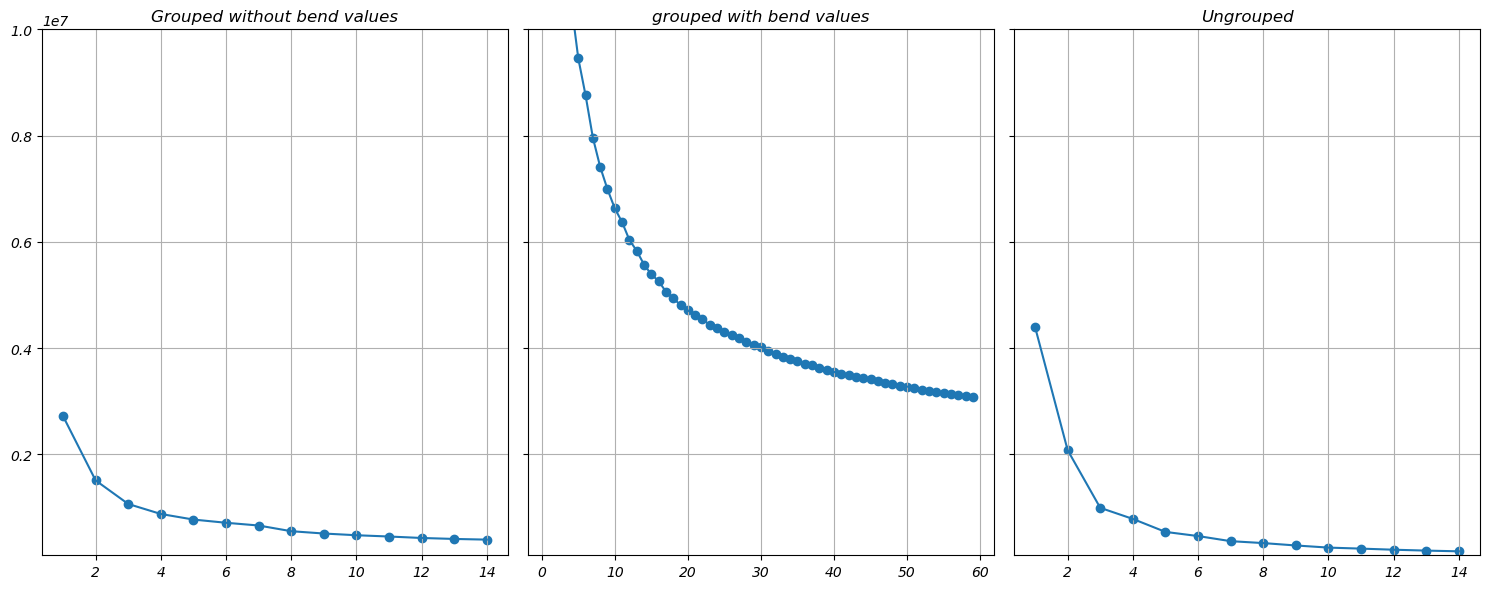

In [35]:
f, ax = plt.subplots(ncols = 3, figsize = [15,6], sharey=True)
ax[0].scatter(krAgg, inertiaAgg)
ax[0].plot(krAgg, inertiaAgg)
ax[0].grid()
ax[0].set_title('Grouped without bend values')

ax[1].scatter(krAll, inertiaAll)
ax[1].plot(krAll, inertiaAll)
ax[1].grid()
ax[1].set_title('grouped with bend values')


ax[2].scatter(krBend, inertiaBend)
ax[2].plot(krBend, inertiaBend)
ax[2].grid()
ax[2].set_title('Ungrouped')

plt.ylim([1e5,1e7])
plt.tight_layout()
plt.show()

# OPTICS

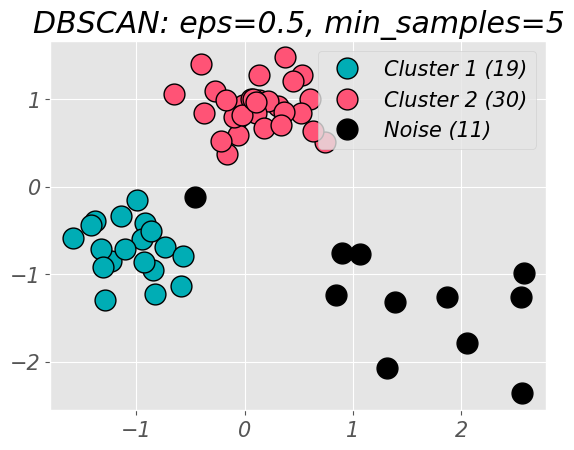

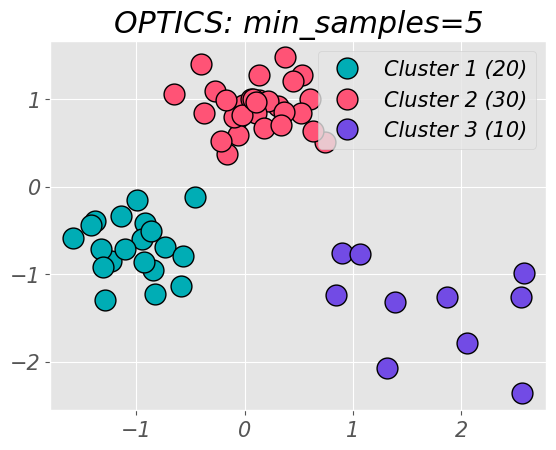

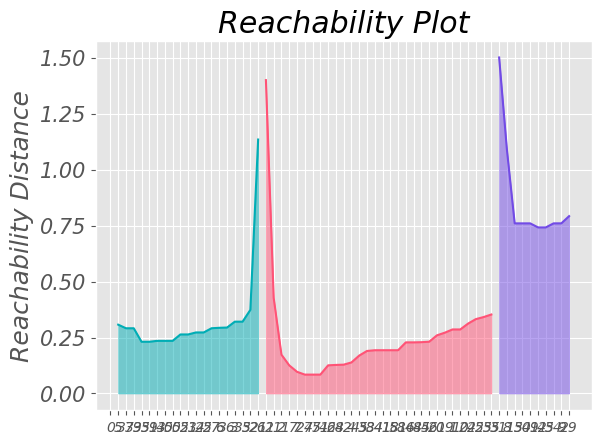

In [4]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN, OPTICS



plt.style.use("ggplot")
colors = ["#00ADB5", "#FF5376", "#724BE5", "#FDB62F"]
plt.rcParams.update({"font.size": 15})


def plot_clusters(algorithm, _df, _min_samples, _eps=""):
   unique_labels = set(_df.labels)
   for k, col in zip(unique_labels, colors[0:len(unique_labels)]):
       # Use black color for noise
       if k == -1:
           col = "k"
       # Use different color per cluster and add labels
       plt.plot(
           _df.loc[_df.labels == k].x,
           _df.loc[_df.labels == k].y,
           "o",
           color=col,
           markeredgecolor="k",
           markersize=15,
           label=(f"Cluster {k+1}" if k != -1 else "Noise")
           + f" ({_df.loc[_df.labels == k].shape[0]})",
       )
   # Add legend and title
   plt.legend(loc="upper right")
   plt.title(
       f"{algorithm}: "
       + (f"eps={_eps}, " if _eps != "" else _eps)
       + f"min_samples={_min_samples}"
   )
   plt.show()


def reachability_plot(_df, model):
   # Get reachability distances and cluster labels
   reachability = model.reachability_[model.ordering_]
   labels = model.labels_[model.ordering_]
   unique_labels = set(labels)
   space = np.arange(len(_df))
   # Generate reachability plot using different color per cluster
   for k, col in zip(unique_labels, colors):
       xk = space[labels == k]
       rk = reachability[labels == k]
       plt.plot(xk, rk, col)
       plt.fill_between(xk, rk, color=col, alpha=0.5)
   # Ordering in x-axis
   plt.xticks(space, _df.index[model.ordering_], fontsize=10)
   # Plot outliers
   plt.plot(space[labels == -1], reachability[labels == -1], "k.", alpha=0.3)
   # Add y-label and title
   plt.ylabel("Reachability Distance")
   plt.title("Reachability Plot")
   plt.show()


if __name__ == "__main__":
   # Generate data
   centers = [[1, 1], [-2, -4], [5, -7]]
   data = make_blobs(
       n_samples=[30, 20, 10],
       centers=centers,
       cluster_std=[0.8, 1, 1.5],
       random_state=0,
   )[0]
   data = StandardScaler().fit_transform(data)
   df = pd.DataFrame(dict(x=data[:, 0], y=data[:, 1]))

   # Define parameters
   eps = 0.5
   min_samples = 5
   metric = "euclidean"

   # Perform DBSCAN clustering and visualize results
   dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric).fit(df)
   df["labels"] = dbscan.labels_
   plot_clusters("DBSCAN", df, str(min_samples), str(eps))

   # Perform OPTICS clustering and visualize results
   optics = OPTICS(min_samples=min_samples, metric=metric).fit(df)
   df["labels"] = optics.labels_
   plot_clusters("OPTICS", df, str(min_samples))
   reachability_plot(df, optics)

# Spatial smoothing

In [4]:
from glob import glob
import networkx as nx
from support import node_position

In [5]:
# add rank to bends withing combinedReach
df['bendRank'] = df.groupby('glob_reach_id')['bendDistOut'].rank(ascending=False).astype(int)
df['bendID']   = df['glob_reach_id'].astype(int).astype(str) + '_' + df['bendRank'].astype(str)

In [71]:
# A = dfB.merge(dfAF, on = 'bendID', how = 'left')
# dfB.shape[0], A.shape[0]
from tqdm import tqdm
import networkx as nx
from datetime import datetime as dt
import pickle

In [95]:
def bend_neighbor_graph(df):
    nodes = []
    edges = []
    for network in tqdm(df['networkGraph'].unique()):
        dfb = df[(df['networkGraph'] == network)]
        for idx, row in dfb.iterrows():
            
            cri  = int(row['combined_reach_id'])
            bri  = row['bendRank']
            rows = dfb[(dfb['combined_reach_id'] == cri)]

            if rows.shape[0] == 1:
                upSide, dnSide = 'up', 'dn'
                upRankID, dnRankID = -1, 0
            elif bri == rows['bendRank'].min():
                upSide, dnSide = 'up', 'id'
                upRankID, dnRankID = -1, bri
            elif bri == rows['bendRank'].max():
                upSide, dnSide = 'id', 'dn'
                upRankID, dnRankID = bri -2, 0
            else:
                upSide, dnSide = 'id', 'id'
                upRankID, dnRankID = bri, bri -2

            upID = row[f'combined_reach_{upSide}']
            dnID = row[f'combined_reach_{dnSide}']

            neighbors = []
            lens      = []
            if ~np.isnan(upID):
                if upID == cri:
                    upR = rows['bendRank'].iloc[upRankID]
                    lens.append(rows['bendLen'].iloc[upRankID])
                    neighbors.append([int(upID),upR])
                else:
                    upR  = dfb.loc[(dfb['combined_reach_id'] == upID), ['bendLen', 'bendRank']]
                    if upR.shape[0] > 0:
                        lens.append(upR['bendLen'].iloc[upRankID])
                        
                        upR = upR['bendRank'].iloc[upRankID]
                        neighbors.append([int(upID),upR])

            if ~np.isnan(dnID):
                if dnID == cri:
                    dnR = rows['bendRank'].iloc[dnRankID]
                    lens.append(rows['bendLen'].iloc[dnRankID])
                    neighbors.append([int(dnID),dnR])
                else:
                    dnR  = dfb.loc[(dfb['combined_reach_id'] == dnID), ['bendLen', 'bendRank']]
                    if dnR.shape[0] > 0:
                        lens.append(dnR['bendLen'].iloc[dnRankID])

                        dnR = dnR['bendRank'].iloc[dnRankID]
                        neighbors.append([int(dnID),dnR])


            sid = f'{cri}_{bri}'
            nodes.append(sid)
            # if cri == 104485:
            #     print(sid, neighbors)

            for i, neighbor in enumerate(neighbors):
                len1 = row['bendLen']
                len2 = lens[i]
                edges.append([sid, f'{neighbor[0]}_{neighbor[1]}', (len1*0.5) + (len2*0.5)])

    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_weighted_edges_from(edges)
    length_dict = dict(nx.all_pairs_dijkstra_path_length(G, weight='weight'))
    
    cont = df['file'].iloc[0]
    with open(directory + f'results/single_smoothed/length_dict_{cont}.pkl', 'wb') as f:
        pickle.dump(length_dict, f)

    return length_dict

In [ ]:
# 3. Smooth attributes using distance-weighted average (1 / path_length)
def smooth_attributes(sid, attr, length_dict, df, max_dist=20000, max_neighbors=7):
    # Get neighbors within a max path distance
    # dist_map = length_dict[sid]
    # dist_map[sid] = 0
    # # print(sid, dist_map)
    # # check that self is included
    # dist_items = [(k, v) for k, v in dist_map.items() if v <= max_dist]

    # dist_items = sorted(dist_items, key=lambda x: x[1])[:max_neighbors]
    # # print(dist_items)
    # if not dist_items:
    #     return df.loc[df['bendID'] == sid, attr].values[0]
    
    # lens = np.array([df.loc[df['bendID'] == k, 'bendLen'].values[0] for k, _ in dist_items])
    
    # dists1      = np.array([d for _, d in dist_items])  
    # dist_sigma1 = lens[0]/2
    # weights1 = np.exp(- (dists1 ** 2) / (2 * dist_sigma1 ** 2))
    # weights1 /= weights1.sum()

    
    # vals1 = []
    # for a in attr:
    #     vals1.append(np.array([df.loc[df['bendID'] == k, a].values[0] for k, _ in dist_items]))
    # dt10 = dt.now()
    # print(dt10-dt1)
    
    dt1 = dt.now()
    dist_map      = length_dict[sid]
    dist_map[sid] = 0
    dist_map      = dict(sorted(dist_map.items(), key=lambda item: item[1]))
    
    dist_keys = np.array(list(dist_map.keys()))
    dist_vals = np.array(list(dist_map.values()))

    mask      = dist_vals < max_dist
    neighbors = dist_keys[mask][:max_neighbors]
    dists     = dist_vals[mask][:max_neighbors]
    if len(neighbors) == 0:
        return df.loc[df['bendID'] == sid, attr].values[0]

    dfF = df.loc[df['bendID'].isin(neighbors), ['bendLen'] +['bendID']+ attr]
    vals  = dfF.set_index('bendID').loc[neighbors].reset_index().values

    dist_sigma = vals[:, 1][0]/2
    weights = np.exp(- (dists ** 2) / (2 * dist_sigma ** 2))
    weights /= weights.sum()

    return np.average(vals[:,2:],  weights=weights, axis = 0)

In [97]:
ldFolder = directory + f'results/single_smoothed/length_dict_{'oc'}.pkl'

with open(ldFolder, 'rb') as f:
    ld = pickle.load(f)


In [276]:
D = dfC.iloc[0:5]['bendID'].apply(lambda sid: smooth_attributes(sid, attr, ld, dfC, max_neighbors=5))

In [119]:
attr = ['slope_left_normalized', 'slope_right_normalized',
        'slope_out_normalized','slope_inn_normalized']
attrS = [f'{a}_smooth' for a in attr]

In [278]:
dfC = df[df['file'] == 'oc'].copy()
dfC['bendRank'] = dfC.groupby('combined_reach_id')['bendDistOut'].rank(ascending=False).astype(int)
dfC['bendID']   = dfC['combined_reach_id'].astype(int).astype(str) + '_' + dfC['bendRank'].astype(str)
for sid in tqdm(dfC['bendID'].values):
    dfC.loc[dfC['bendID'] == sid, attrS] = smooth_attributes(sid, attr, ld, dfC, max_neighbors=5)

100%|██████████| 107150/107150 [29:54<00:00, 59.70it/s]


In [281]:
dfNC = dfC.to_xarray()
ncFile = directory + f'results/single_smoothed/global_{50}_{'02'}_smoothed.nc'
if os.path.exists(ncFile):
    os.remove(ncFile)

dfNC.to_netcdf(ncFile)

In [ ]:
import os
cross = 50
hf = '02'

def run_bend_smoothing(df, cont):
    df = df[df['file'] == cont].copy()
    # add rank to bends withing combinedReach
    df['bendRank'] = df.groupby('combined_reach_id')['bendDistOut'].rank(ascending=False).astype(int)
    df['bendID']   = df['combined_reach_id'].astype(int).astype(str) + '_' + df['bendRank'].astype(str)

    df = df.sort_values(['file', 'combined_reach_id', 'bendRank'])
    
    ldFolder = directory + f'results/single_smoothed/length_dict_{cont}.pkl'
    if os.path.exists(ldFolder):
        with open(ldFolder, 'rb') as f:
            ld = pickle.load(f)
    else:
        ld = bend_neighbor_graph(df)


    attr = ['slope_left_normalized', 'slope_right_normalized',
                    'slope_out_normalized','slope_inn_normalized']
    attrS = [f'{a}_smooth' for a in attr]
    for sid in tqdm(df['bendID'].values):
        df.loc[df['bendID'] == sid, attrS] = smooth_attributes(sid, attr, ld, df, max_neighbors=5)

    print('Create smooth vars done')
    dfNC = df.to_xarray()
    ncFile = directory + f'results/single_smoothed/{cont}_{cross}_{hf}_smoothed.nc'
    if os.path.exists(ncFile):
        os.remove(ncFile)

    dfNC.to_netcdf(ncFile)
run_bend_smoothing(df, 'oc')

100%|██████████| 676/676 [01:03<00:00, 10.71it/s]


KeyboardInterrupt: 

In [200]:
def create_multiprocess_iterator(df):
    multiIterator = df.groupby(['file', 'networkGraph'], as_index = False)['index'].count()
    multiIterator = multiIterator.sort_values('index', ascending = False).reset_index()

    threshold = 5000
    multiIterator['networkGroup'] = -1

    for f in ['oc', 'af', 'sa', 'as', 'na', 'eu']:
        mi = multiIterator[multiIterator['file'] == f]
        group, groupSize = [], 0
        for i, r in mi.iterrows():
            if r['index'] > threshold:
                multiIterator.loc[i, 'networkGroup'] = multiIterator['networkGroup'].max() + 1
            else:
                group.append(i)
                groupSize += r['index']
                if groupSize > threshold:
                    multiIterator.loc[group, 'networkGroup'] = multiIterator['networkGroup'].max() + 1
                    group, groupSize = [], 0

            if (i == mi.index[-1]) & (len(group) != 0):
                if groupSize > threshold:
                    val = multiIterator['networkGroup'].max() + 1
                else:
                    val = multiIterator['networkGroup'].max() 
                multiIterator.loc[group, 'networkGroup'] = val
    multiIterator['networkGroupSize'] = multiIterator.groupby('networkGroup')['index'].transform('sum')
    multiIterator = multiIterator.sort_values('networkGroupSize', ascending = False)

    grouped = multiIterator.groupby(['file', 'networkGroup'], as_index = False).agg({'networkGraph': list,
                                                                                    'networkGroupSize':'first'}).reset_index()
    it = grouped.sort_values('networkGroupSize', ascending=False)[['file', 'networkGraph']].values
    return it
    

In [197]:
N, E = [],[]
for mu in [A[-1]]:
    nodes, edges = bend_neighbor_graph(mu, df)
    N.append(nodes)
    E.append(edges)

oc [19, 126, 180, 265, 363, 63, 296, 78, 389, 158, 313, 219, 183, 607, 462, 530, 546, 402, 186, 30, 416, 324, 569, 17, 436, 631, 596, 468, 142, 212, 649, 297, 66, 70, 655, 184, 101, 350, 562, 672, 409, 434, 274, 294, 322, 27, 13, 411, 442]


100%|██████████| 5002/5002 [00:17<00:00, 293.86it/s]


In [56]:
NN = [i for n in N for i in n]
EE = [i for n in E for i in n]

In [59]:
G = nx.Graph()
G.add_nodes_from(NN)
G.add_weighted_edges_from(EE)


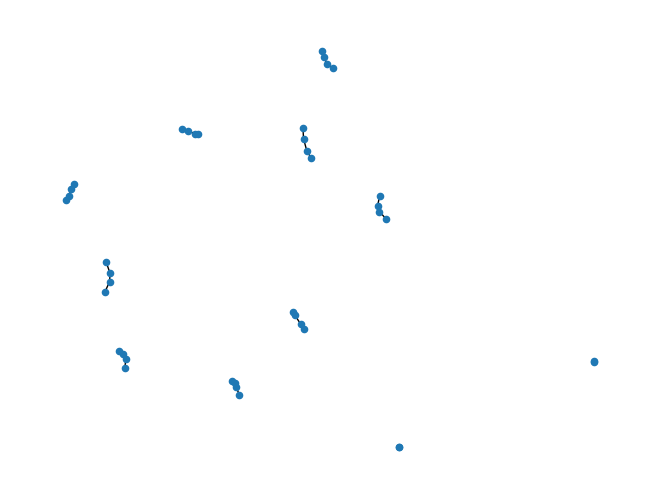

In [60]:
nx.draw(G, node_size =20, with_labels = False)

In [50]:
components = list(nx.connected_components(G))
lens = [len(c) for c in components]
components

[{'2726_1'},
 {'11486_1'},
 {'57276_1'},
 {'6553_1'},
 {'11518_1'},
 {'4225_1'},
 {'56577_1'},
 {'6552_1'},
 {'1946_1'},
 {'4090_1'},
 {'7182_1'},
 {'1177_1'},
 {'30575_1'},
 {'9723_1'},
 {'7329_1'},
 {'9720_1'},
 {'4227_1', '4227_2'},
 {'4441_1', '4441_2'},
 {'7228_1', '7228_2'},
 {'11502_1', '11502_2'},
 {'9872_1', '9872_2'},
 {'9338_1', '9338_2'},
 {'9722_1', '9722_2'},
 {'4439_1', '4439_2'},
 {'13716_1', '13716_2'},
 {'7941_1', '7941_2'},
 {'11603_1', '11603_2'},
 {'5569_1', '5569_2', '5569_3'},
 {'5831_1', '5831_2', '5831_3'},
 {'8947_1', '8947_2', '8947_3'},
 {'2602_1', '2602_2', '2602_3'},
 {'2605_1', '2605_2', '2605_3'},
 {'11512_1', '11512_2', '11512_3'},
 {'24143_1', '24143_2', '24143_3'},
 {'43076_1', '43076_2', '43076_3'},
 {'11671_1', '11671_2', '11671_3'},
 {'0_1'},
 {'1_1'},
 {'2_1'},
 {'17458_1'},
 {'17459_1', '17459_2'},
 {'23666_1', '23666_2', '23666_3'},
 {'13679_1', '13679_2', '13680_1'},
 {'18981_1', '18981_2', '18981_3'},
 {'4939_1', '4939_2', '4939_3'},
 {'11487_

In [51]:
G.edges

EdgeView([('4227_1', '4227_2'), ('4441_1', '4441_2'), ('7228_1', '7228_2'), ('11502_1', '11502_2'), ('9872_1', '9872_2'), ('9338_1', '9338_2'), ('9722_1', '9722_2'), ('4439_1', '4439_2'), ('13716_1', '13716_2'), ('7941_1', '7941_2'), ('11603_1', '11603_2'), ('5569_1', '5569_2'), ('5569_2', '5569_3'), ('5831_1', '5831_2'), ('5831_2', '5831_3'), ('8947_1', '8947_2'), ('8947_2', '8947_3'), ('2602_1', '2602_2'), ('2602_2', '2602_3'), ('2605_1', '2605_2'), ('2605_2', '2605_3'), ('11512_1', '11512_2'), ('11512_2', '11512_3'), ('24143_1', '24143_2'), ('24143_2', '24143_3'), ('43076_1', '43076_2'), ('43076_2', '43076_3'), ('11671_1', '11671_2'), ('11671_2', '11671_3'), ('17459_1', '17459_2'), ('23666_1', '23666_2'), ('23666_2', '23666_3'), ('13679_1', '13679_2'), ('13679_2', '13680_1'), ('18981_1', '18981_2'), ('18981_2', '18981_3'), ('4939_1', '4939_2'), ('4939_2', '4939_3'), ('11487_1', '11487_2'), ('11487_2', '11487_3'), ('6745_1', '6745_2'), ('6745_2', '6745_3'), ('56549_1', '56549_2'), ('

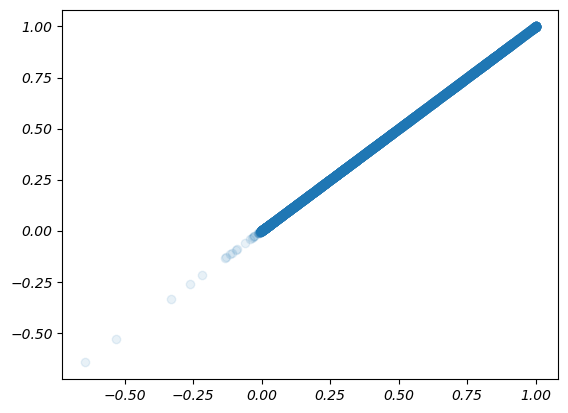

In [146]:
plt.scatter(dfb['slope_left_normalized_smooth'], dfb['slope_out_normalized_smooth'], alpha = 0.1)

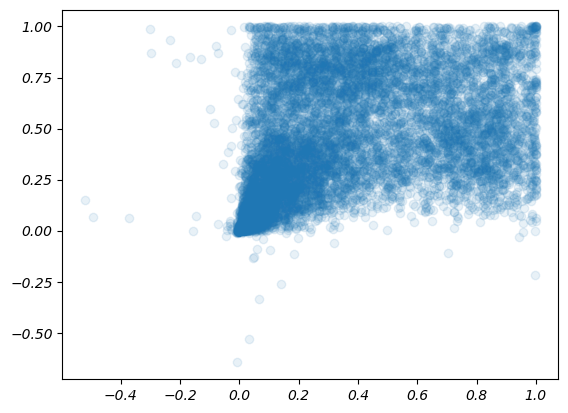

In [144]:
plt.scatter(dfb['slope_inn_normalized_smooth'], dfb['slope_out_normalized_smooth'], alpha = 0.1)

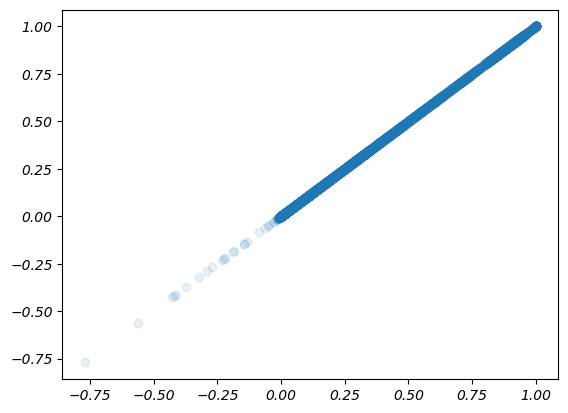

In [147]:
plt.scatter(dfb['slope_left_normalized'], dfb['slope_out_normalized'], alpha = 0.1)

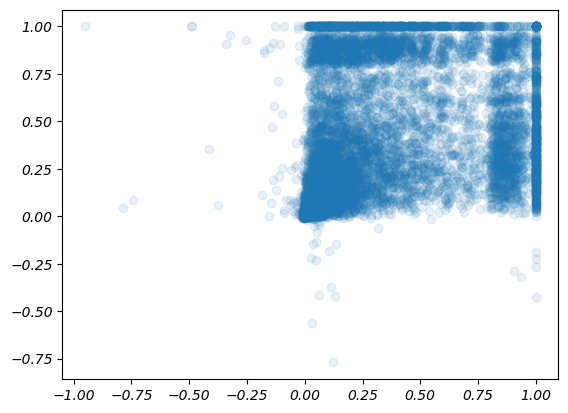

In [145]:
plt.scatter(dfb['slope_inn_normalized'], dfb['slope_out_normalized'], alpha = 0.1)

/tmp/ipykernel_171349/1283160276.py:2: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


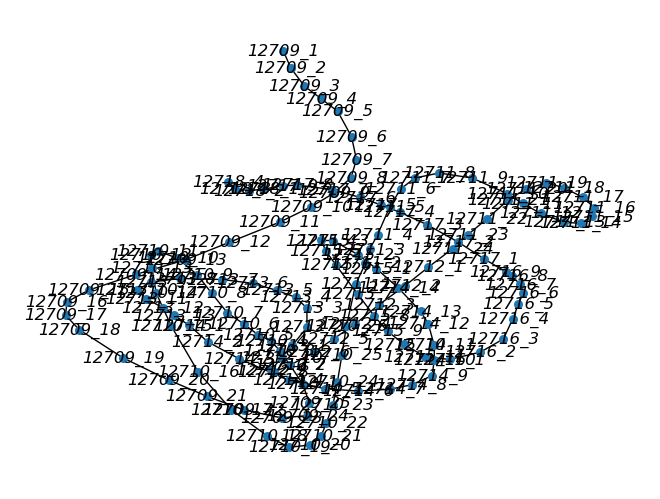

In [50]:
nx.draw(G, node_size =30, with_labels = True)
plt.tight_layout()

In [75]:
list(nx.connected_components(G))

[{12709.0,
  12710.0,
  12711.0,
  12712.0,
  12713.0,
  12714.0,
  12715.0,
  12716.0,
  12717.0,
  12718.0},
 {12724.0,
  12725.0,
  12726.0,
  12727.0,
  12728.0,
  12729.0,
  12730.0,
  12731.0,
  12732.0},
 {12733.0, 12734.0, 12735.0, 12736.0, 12737.0},
 {12751.0,
  12752.0,
  12753.0,
  12754.0,
  12755.0,
  12756.0,
  12757.0,
  12758.0,
  12759.0,
  12760.0,
  12761.0,
  12762.0},
 {12774.0, 12775.0, 12776.0},
 {12770.0, 12771.0}]

In [67]:
dfR[dfR['combined_reach_id'] == 12773][['reach_id', 'combined_reach_dn']]

,reach_id,combined_reach_dn
43,18170800661,NaN


In [1]:
GC = nx.Graph()
df.groupby('glob_reach_id', as_index = False)['combined_reach_id', 'reach_id', 'glob_reach_id', 'file', 'rch_id_up', 'rch_id_dn', 'rch_id_up_orig', 'rch_id_dn_orig']

NameError: name 'nx' is not defined

In [15]:
# Add nodes with attributes
for idx, row in d.iterrows():
    G.add_node(row['bend_id'], attr=row[['bendLen', 'ER_out']].to_dict())


False

In [ ]:
for idx, row in d.iterrows():
    sid = row['bend_id']
    G.add_node(sid)
    # connected BENDS
    dfReachRow = df[(df['combined_reach_id'] == row['combined_reach_id']) & (df['file'] == 'af')].iloc[0]
    gdfReachRows = d[d['combined_reach_id'] == row['combined_reach_id']]
    bendids = gdfReachRows['bend_id'] 
    if gdfReachRows['bendRank'].max() > 1:
        if sid == bendids.min():
            conReach = 
            conReaches = [sid+1, ]
        elif sid == bendids.max():
            dnr = dfReachRow['dn_connected']
            if ~np.isnan(dnr):
                conReaches = [sid-1, dnr]
        else:
            conReaches = [sid-1, sid+1]

        for neighbor in row['dn_connected_reach']:
            # Edge weight = average of section and neighbor length
            len1 = row['bend_len'] * 0.5
            len2 = gdf.loc[gdf['Section_ID'] == neighbor, 'length'].values[0]
            G.add_edge(sid, neighbor, weight=(len1 + len2)/2)
    else:
        single bend in reach

# 2. Compute all-pairs shortest path lengths (along-river distance)
length_dict = dict(nx.all_pairs_dijkstra_path_length(G, weight='weight'))

12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12710.0
12711.0
12711.0
12711.0
12711.0
12711.0
12711.0
12711.0
12711.0
12711.0
12711.0
12711.0
12711.0
12711.0
12711.0
12711.0
12711.0
12711.0
12711.0
12711.0
12711.0
12711.0
12711.0
12711.0
12711.0
12712.0
12712.0
12712.0
12712.0
12712.0
12712.0
12712.0
12712.0
12712.0
12712.0
12713.0
12713.0
12713.0
12713.0
12713.0
12713.0
12713.0
12713.0
12713.0
12713.0
12713.0
12713.0
12713.0


In [ ]:
# 1. Load your dataset (modify to your file path)
gdf = gpd.read_file("your_river_sections.geojson")  # Or .shp or other

# 2. Make sure 'connected_to' is a list (if it's a string in the file)
if isinstance(gdf['connected_to'].iloc[0], str):
    gdf['connected_to'] = gdf['connected_to'].apply(ast.literal_eval)

# 3. Build graph of sections
G = nx.Graph()

# Add nodes with attributes
for idx, row in gdf.iterrows():
    G.add_node(row['Section_ID'], attr=row[['width', 'depth', 'velocity']].to_dict())

# Add edges based on connected_to list
for idx, row in gdf.iterrows():
    for neighbor in row['connected_to']:
        G.add_edge(row['Section_ID'], neighbor)

# 4. Compute neighborhood-averaged features
# For each node, average its own and its neighbors’ attributes
def smooth_attributes(section_id):
    neighbors = list(G.neighbors(section_id)) + [section_id]  # Include self
    attrs = np.array([
        [G.nodes[n]['attr']['width'], G.nodes[n]['attr']['depth'], G.nodes[n]['attr']['velocity']]
        for n in neighbors
    ])
    return attrs.mean(axis=0)

# Apply smoothing
smoothed = np.array([smooth_attributes(sid) for sid in gdf['Section_ID']])
gdf[['width_smooth', 'depth_smooth', 'velocity_smooth']] = smoothed

# # 5. Normalize smoothed features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(smoothed)

# # 6. Run clustering
# clusterer = hdbscan.HDBSCAN(min_cluster_size=5)
# labels = clusterer.fit_predict(X_scaled)
# gdf['cluster'] = labels

# # 7. Plot result
# gdf.plot(column='cluster', legend=True, cmap='Set1', figsize=(10, 6))
# plt.title("Clustering of River Sections Using Connected Reaches")
# plt.axis('off')
# plt.show()


DriverError: your_river_sections.geojson: No such file or directory

In [36]:
F = glob(directory +'results/single_values/*50.csv')[1]
A = pd.read_csv(F)

In [44]:
A.columns

Index(['Unnamed: 0', 'combined_reach_id', 'reach_id', 'reach_len', 'n_nodes',
       'wse', 'width', 'facc', 'n_chan_max', 'n_chan_mod', 'obstr_type',
       'grod_id', 'hfalls_id', 'slope', 'dist_out', 'lakeflag', 'max_width',
       'n_rch_up', 'n_rch_dn', 'rch_id_up', 'rch_id_dn', 'swot_orbit', 'type',
       'river_name', 'path_freq', 'path_order', 'path_segs', 'main_side',
       'strm_order', 'end_reach', 'network', 'include_flag', 'pfaf1', 'pfaf2',
       'localCRS', 'rch_id_up_orig', 'rch_id_dn_orig', 'n_rch_up_orig',
       'n_rch_dn_orig', 'node_mean_max_width', 'dn_connected_reach',
       'river_segment', 'river_segment_order', 'reach_order',
       'dn_river_segment', 'combined_reach_len', 'combined_reach_width',
       'combined_reach_max_width', 'networkGraph', 'networkGroup',
       'max_dist_out', 'up_reach_id', 'catchment_position', 'geometry',
       'combined_reach_crs', 'widthRatio', 'sin', 'bendSin', 'apex', 'apexP',
       'ang', 'infP', 'bendLines', 'bendWidths'

In [41]:
from glob import glob
files = glob(directory +'results/single_values/*50_02*gpkg')
filesAll = glob(directory +'results/all/*50*')
dfL = gpd.read_file(files[0])
# D = pd.read_csv(filesAll[0])

In [43]:
D.columns

Index(['x', 'y', 'reach_id', 'reach_len', 'n_nodes', 'wse', 'wse_var', 'width',
       'width_var', 'facc', 'n_chan_max', 'n_chan_mod', 'obstr_type',
       'grod_id', 'hfalls_id', 'slope', 'dist_out', 'lakeflag', 'max_width',
       'n_rch_up', 'n_rch_dn', 'rch_id_up', 'rch_id_dn', 'swot_orbit',
       'swot_obs', 'type', 'river_name', 'edit_flag', 'trib_flag', 'path_freq',
       'path_order', 'path_segs', 'main_side', 'strm_order', 'end_reach',
       'network', 'include_flag', 'pfaf1', 'pfaf2', 'localCRS',
       'rch_id_up_orig', 'rch_id_dn_orig', 'n_rch_up_orig', 'n_rch_dn_orig',
       'node_mean_max_width', 'dn_connected_reach', 'river_segment',
       'river_segment_order', 'reach_order', 'combined_reach_id',
       'dn_river_segment', 'combined_reach_len', 'combined_reach_width',
       'combined_reach_max_width', 'networkGraph', 'networkGroup',
       'max_dist_out', 'up_reach_id', 'catchment_position', 'geometry',
       'combined_reach_crs', 'widthRatio', 'sin', 'bendSin',

In [42]:
dfL.columns

Index(['reach_id', 'combined_reach_id', 'apex', 'bendWidths', 'bendMaxWidths',
       'ang', 'sin', 'bendSin', 'cp_height', 'ER_out', 'ER_inn', 'ER_left',
       'ER_right', 'slope_out', 'slope_inn', 'slope_left', 'slope_right',
       'bendDistOut', 'geometry'],
      dtype='object')

In [22]:
for CI in D['combined_reach_id'].unique():
    rows = D[D['combined_reach_id'] == CI]
    if (rows['localCRS'].nunique() > 1) & (rows['localCRS'].nunique() > 0):
        print('test', CI)


test 3724.0
test 3970.0
test 4053.0
test 4169.0
test 4168.0
test 3448.0
test 4737.0
test 4947.0
test 4946.0
test 5110.0
test 4935.0
test 5356.0
test 5788.0
test 3445.0
test 6090.0
test 6425.0
test 6646.0


In [24]:
rows = D[D['combined_reach_id'] == 3724]
rows['localCRS']

730    EPSG:32733
731    EPSG:32734
734    EPSG:32733
735    EPSG:32733
Name: localCRS, dtype: object